In [1]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.linalg import eigh, inv
import pandas as pd
from nki_rs2_eeg.config import (SESSION_ID, TASK_ID, RUN_ID, DERIVATIVES_DIR, CONCAT_DATA_DIR, RAW_DATA_DIR)

def make_channel_df(task_id):
    channel_files = list(DERIVATIVES_DIR.rglob(f"sub*/ses-MOBI1A/eeg/sub-*_ses-MOBI1A_task-{task_id}_run-1_channels.tsv"))
# Combine all channel files into a single DataFrame
    channels_df = pd.concat([pd.read_csv(file, sep='\t') for file in channel_files])
    sub_ids = [file.parts[-4] for file in channel_files]
    channels_df['subject'] = np.repeat(sub_ids, 64)
    channels_df['is_bad'] = channels_df['status'] == 'bad'
    return channels_df

In [4]:
pp_chanels_df = make_channel_df("passivepresent")
# for each subject get the sum of the boolean columns
pp_bool = pp_chanels_df.groupby('subject')[pp_chanels_df.select_dtypes(include='bool').columns].sum()
pp_bool['stimulus'] = "passivepresent"

ps_chanels_df = make_channel_df("passivesherlock")
ps_bool = ps_chanels_df.groupby('subject')[ps_chanels_df.select_dtypes(include='bool').columns].sum()
ps_bool['stimulus'] = "passivesherlock"

In [5]:

channels = pd.concat([pp_bool, ps_bool], ignore_index=True)
# Convert the channels dataframe to long format for seaborn
channels_long = channels.melt(id_vars=['stimulus'], value_vars=[ 'bad_by_nan', 'bad_by_flat',
                                                               'bad_by_deviation', 'bad_by_hf_noise', 'bad_by_correlation', 'bad_by_SNR', 'bad_by_dropout', 'bad_by_psd', 'bad_by_ransac', 'is_bad' ], var_name='channel_status', value_name='count')

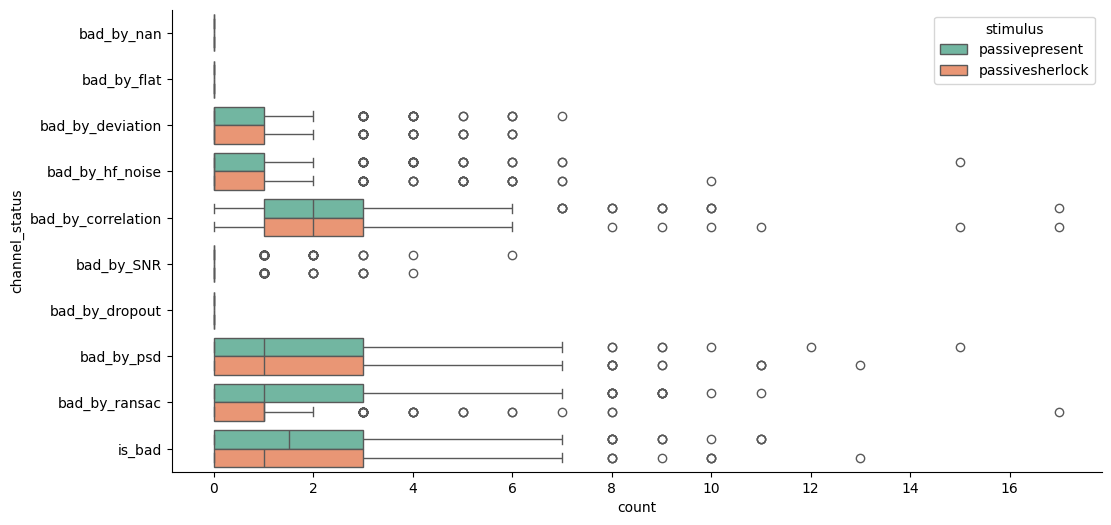

In [6]:
#make a boxplot of the distribution of bad channels in each category across subjects with stimulus as the hue variable
from matplotlib import ticker


fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(y="channel_status", x="count", hue="stimulus", data=channels_long, palette='Set2')
# make the x axis labels more readable
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)   
# make the x axis only show integer ticks and set the y axis limits to 0 and 20

#only whole numbers on the x axis
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# move the y=0 up 

# ISC 

In [4]:
task = "passivesherlock"
subject_isc = np.load(DERIVATIVES_DIR / f"sub-ALL_ses-{SESSION_ID}_task-{TASK_ID}_run-{RUN_ID}_isc_per_subject.npy")
subject_order = np.load(DERIVATIVES_DIR / f"sub-ALL_ses-{SESSION_ID}_task-{TASK_ID}_run-{RUN_ID}_isc_sub_order.npy")
subject_order = [s.split('-')[1].split('_')[0] for s in subject_order]
subject_age = pd.read_csv("/home/bgonzalez/NKI_RS2_EEG/data/RS2_age.csv", sep=',')
subject_age['subject'] = subject_age['a_number']#%%



sub_isc_df = pd.DataFrame({
    'subject': subject_order,
    'ISC': subject_isc
})
sub_isc_df = sub_isc_df.merge(subject_age, on='subject')
sub_isc_df.head()

,subject,ISC,ursi,a_number,mri_age_yr
0,A00017133,-0.000012,M10969036,A00017133,65.0
1,A00077134,-0.000325,M10989973,A00077134,74.0
2,A00077622,0.000037,M10928777,A00077622,76.0
3,A00079353,-0.000181,M10973007,A00079353,38.0
4,A00075407,0.000063,M10972828,A00075407,73.0


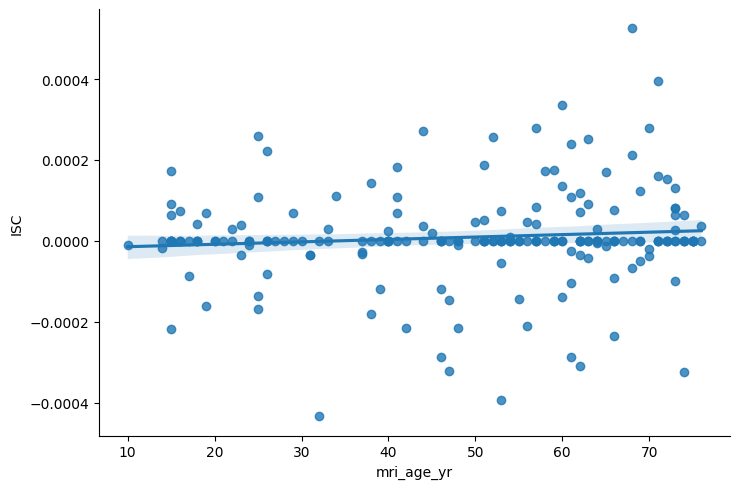

In [5]:
sns.lmplot(x='mri_age_yr', y='ISC', data=sub_isc_df, aspect=1.5)

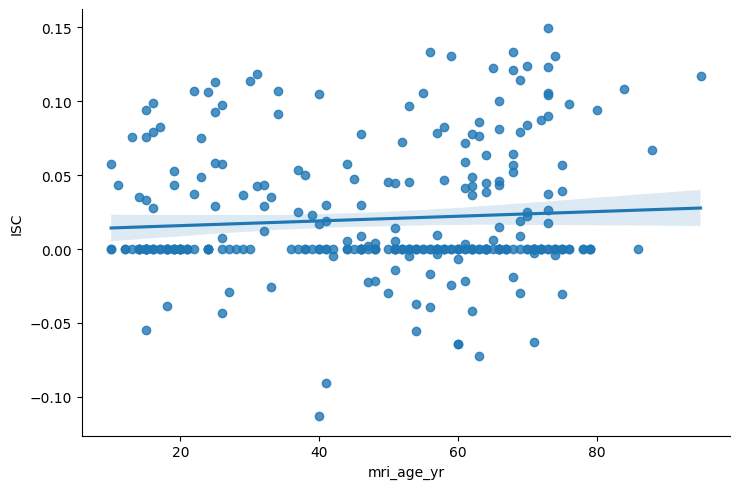

In [2]:
task = "passivepresent"
subject_isc = np.load(DERIVATIVES_DIR / f"sub-ALL_ses-{SESSION_ID}_task-{task}_run-{RUN_ID}_isc_per_subject.npy")
subject_order = np.load(DERIVATIVES_DIR / f"sub-ALL_ses-{SESSION_ID}_task-{task}_run-{RUN_ID}_isc_sub_order.npy")
subject_order = [s.split('-')[1].split('_')[0] for s in subject_order]
subject_age = pd.read_csv("/home/bgonzalez/NKI_RS2_EEG/data/RS2_age.csv", sep=',')
subject_age['subject'] = subject_age['a_number']#%%



sub_isc_df = pd.DataFrame({
    'subject': subject_order,
    'ISC': subject_isc
})
sub_isc_df = sub_isc_df.merge(subject_age, on='subject')
sns.lmplot(x='mri_age_yr', y='ISC', data=sub_isc_df, aspect=1.5)

In [ ]:
# plot the distibution of bad channels across subjects with mean and 2 standard deviations
plt.figure(figsize=(10, 6))
plt.hist(channels.is_bad, bins=20, alpha=0.7, color='blue')
plt.axvline(channels.is_bad.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(channels.is_bad.mean() + 2*channels.is_bad.std(), color='green', linestyle='dashed', linewidth=1)
plt.axvline(channels.is_bad.mean() - 2*channels.is_bad.std(), color='green', linestyle='dashed', linewidth=1)
plt.title('Distribution of Bad Channels Across Subjects')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# how many subjects have more than 6 bad channels?
print(f"{(channels.is_bad > 6).sum()} subjects have more than 6 bad channels")

subject_exclusions = channels[channels.is_bad > 6].index.tolist()
subject_exclusions

In [ ]:
subject_isc = np.load(DERIVATIVES_DIR / "sub-ALL_ses-MOBI1A_task-passivepresent_run-1_isc_per_subject.npy")
subject_order = np.load(DERIVATIVES_DIR / "sub-ALL_ses-MOBI1A_task-passivepresent_run-1_isc_sub_order.npy")
subject_age = pd.read_csv("/home/bgonzalez/NKI_RS2_EEG/data/RS2_age.csv", sep=',')

subject_age.head()

In [ ]:
print('hey')